# Camera Calibration Basics

This notebook is the second major Stage 1 checkpoint in `vision-imaging-lab`.

## Goals
- understand why cameras need calibration
- learn the difference between squares and inner corners
- detect chessboard corners in calibration images
- prepare object points and image points for calibration
- estimate camera parameters
- visualize undistortion

## Important note
This notebook uses the OpenCV sample chessboard dataset to learn the calibration pipeline.
It is a practical example of real calibration images and a good starting point for understanding the workflow.


## Notebook Roadmap

This notebook is organized as a guided calibration walkthrough:

1. Define the chessboard pattern correctly
2. Load the calibration dataset
3. Detect chessboard corners
4. Understand object points and image points
5. Estimate the camera matrix and distortion coefficients
6. Visualize undistortion
7. Interpret the calibration result
8. Summarize what this calibration workflow teaches us

The goal is to understand the calibration pipeline, not just run the OpenCV function.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Project root:", project_root)
print("Source path:", src_path)

Project root: E:\Workspace\vision-imaging-lab
Source path: E:\Workspace\vision-imaging-lab\src


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from image_utils import get_project_root

## 1. Calibration pattern definition

OpenCV chessboard calibration uses **inner corners**, not the number of squares.

For the OpenCV real sample dataset used here:
- the board pattern is `7 x 6` inner corners
- this is the pattern size we must pass to OpenCV

This is one of the most important details in the calibration pipeline.
If the pattern size is wrong, corner detection will fail.


In [3]:
pattern_size = (7, 6)  # inner corners: columns, rows
square_size = 1.0      # arbitrary unit for learning

calibration_dir = project_root / "data" / "calibration"
image_paths = sorted(calibration_dir.glob("*.jpg"))

print("Pattern size (inner corners):", pattern_size)
print("Number of calibration images:", len(image_paths))
for path in image_paths[:5]:
    print(path.name)


Pattern size (inner corners): (7, 6)
Number of calibration images: 13
left01.jpg
left02.jpg
left03.jpg
left04.jpg
left05.jpg


### Theory: pattern geometry and why inner corners matter

OpenCV calibration does not use the number of black and white squares directly.
It uses the grid of **inner corner intersections**.

For a pattern with `7 x 6` inner corners, the detector is searching for a lattice of:

$$7 \times 6 = 42$$

ordered points.

### Why inner corners are used
Corners are stable geometric features:
- they have clear local structure
- they can be detected more precisely than square regions
- they provide repeatable point correspondences across images

### Pseudocode
```text
choose correct inner-corner pattern size
load each calibration image
search for the full corner lattice
keep only successful detections
```


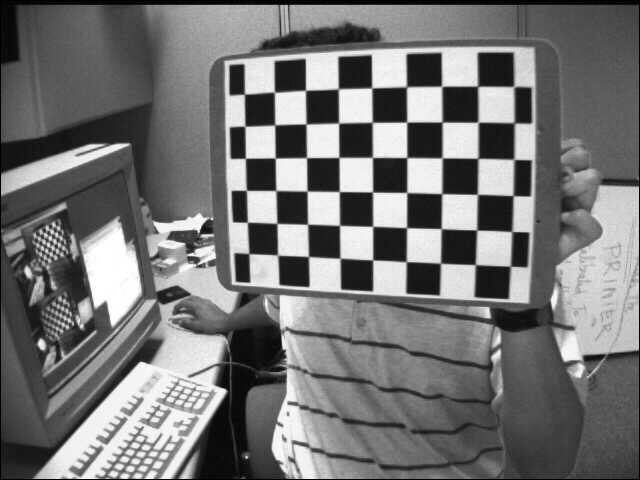

In [4]:
example_image_path = image_paths[0]
display(Image(filename=str(example_image_path)))


## 2. Detect chessboard corners

The next step is to detect the inner chessboard corners in each calibration image.

These detected 2D image points will later be matched with known 3D object points from the chessboard pattern.

If the corners are detected correctly, we can move on to calibration.

In [5]:
found_results = []
image_points = []
successful_image_paths = []

for image_path in image_paths:
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    found, corners = cv2.findChessboardCorners(gray, pattern_size)

    found_results.append((image_path.name, found))

    if found:
        image_points.append(corners)
        successful_image_paths.append(image_path)

for name, found in found_results:
    print(f"{name}: {'found' if found else 'not found'}")

print("\nSuccessful detections:", len(successful_image_paths), "/", len(image_paths))

left01.jpg: found
left02.jpg: found
left03.jpg: found
left04.jpg: not found
left05.jpg: not found
left06.jpg: found
left07.jpg: found
left08.jpg: found
left09.jpg: not found
left11.jpg: not found
left12.jpg: found
left13.jpg: found
left14.jpg: found

Successful detections: 9 / 13


### Theory: chessboard corner detection as structured feature detection

`findChessboardCorners` is not simply detecting isolated points.
It is trying to recover a complete ordered grid that satisfies the expected chessboard structure.

That is why some images can fail even when the board is visible:
- the full grid may be too distorted
- the corner pattern may be difficult to localize reliably
- the ordering may become ambiguous under strong perspective

The important requirement is not "board visible" but:
- full pattern geometry detectable
- ordering internally consistent


## 3. Visualize detected corners

It is important not to trust the detection blindly.  
We should draw the detected corners on the images and inspect them visually.

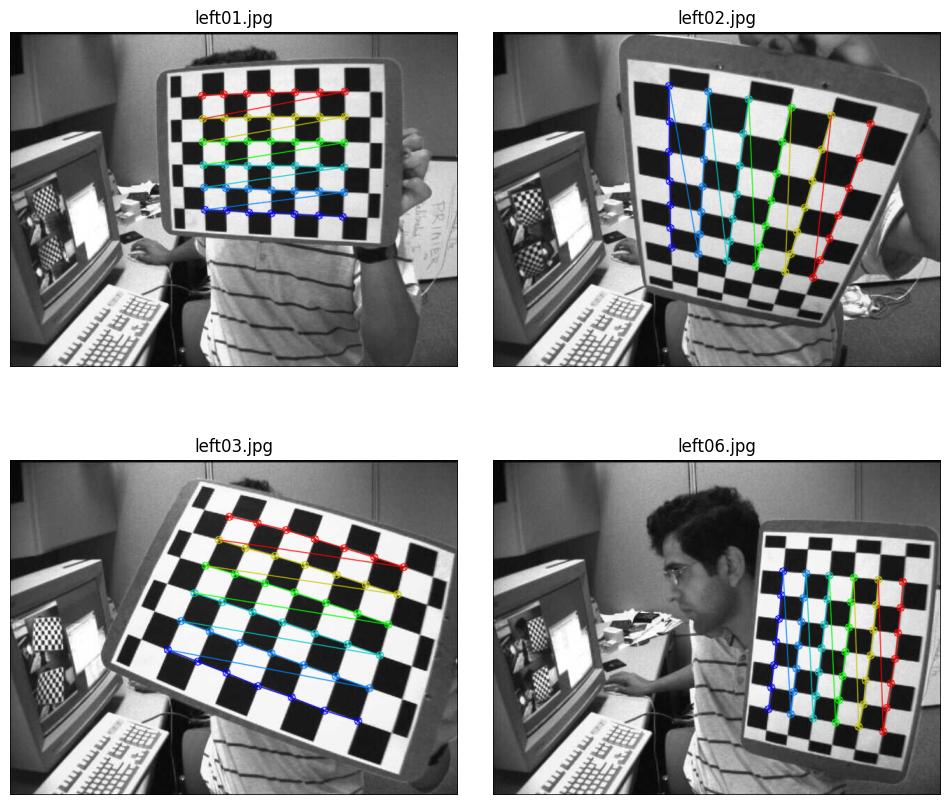

In [6]:
num_show = min(4, len(successful_image_paths))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.subplots_adjust(hspace=0.25, wspace=0.08)

for ax, image_path, corners in zip(axes.flat, successful_image_paths[:num_show], image_points[:num_show]):
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    drawn = cv2.drawChessboardCorners(image_rgb.copy(), pattern_size, corners, True)

    ax.imshow(drawn)
    ax.set_title(image_path.name)
    ax.axis("off")

# Hide unused axes if fewer than 4 images
for ax in axes.flat[num_show:]:
    ax.axis("off")
    
plt.show()

## 3b. Inspect corner ordering with indices

Color alone can make the ordering feel ambiguous.
To verify the detection more clearly, we can draw the corner index number at each detected point.

This helps us see whether the detected sequence follows the chessboard grid consistently.

In [7]:
def draw_corner_indices(image_rgb, corners, max_points=None):
    output = image_rgb.copy()
    points = corners.reshape(-1, 2)

    if max_points is None:
        max_points = len(points)

    for i, (x, y) in enumerate(points[:max_points]):
        cv2.circle(output, (int(x), int(y)), 5, (255, 0, 0), -1)
        cv2.putText(
            output,
            str(i),
            (int(x) + 6, int(y) - 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1,
            cv2.LINE_AA,
        )
    return output

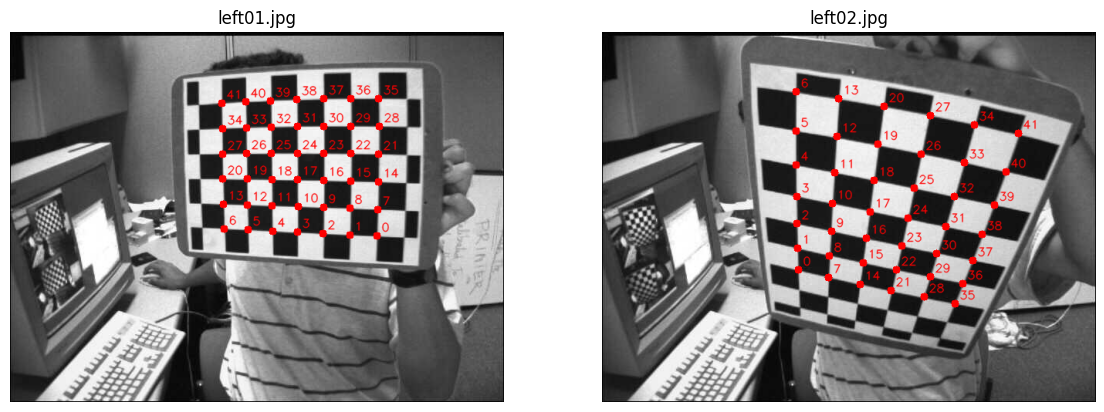

In [8]:
selected_names = ["left01.jpg", "left02.jpg"]

selected_rows = []
for target_name in selected_names:
    for image_path, corners in zip(successful_image_paths, image_points):
        if image_path.name == target_name:
            selected_rows.append((image_path, corners))
            break

fig, axes = plt.subplots(1, len(selected_rows), figsize=(14, 6))
if len(selected_rows) == 1:
    axes = [axes]

for ax, (image_path, corners) in zip(axes, selected_rows):
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    indexed = draw_corner_indices(image_rgb, corners)

    ax.imshow(indexed)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.show()

### Theory: why point indices matter

Calibration assumes a one-to-one correspondence:

- `object_points[i]` is the known 3D corner in board coordinates
- `image_points[i]` is the detected 2D corner in pixel coordinates

If the indexing were inconsistent across images, calibration would be wrong.

The key is not that a corner appears on the same side of the image every time.
The key is that the same index refers to the same **board-local corner** in every image.

Because the board rotates in the image, the visual side can change while the board-local identity stays the same.


### Interpretation

If corner detection succeeds across many images and the drawn points align with the chessboard pattern, the calibration dataset is suitable for the next step.

For a real dataset, it is normal that not every image succeeds.
Some views may be too oblique, partially cropped, or difficult for corner detection.
What matters is having enough successful detections with varied viewpoints.


## 3c. Inspect failed detections

If some images fail corner detection, it is useful to inspect them directly.

Typical reasons include:
- extreme perspective
- partial visibility
- blur
- weak contrast
- difficult corner geometry

In [9]:
failed_image_paths = []

for image_path, (name, found) in zip(image_paths, found_results):
    if not found:
        failed_image_paths.append(image_path)

print("Failed images:")
for path in failed_image_paths:
    print(path.name)

Failed images:
left04.jpg
left05.jpg
left09.jpg
left11.jpg


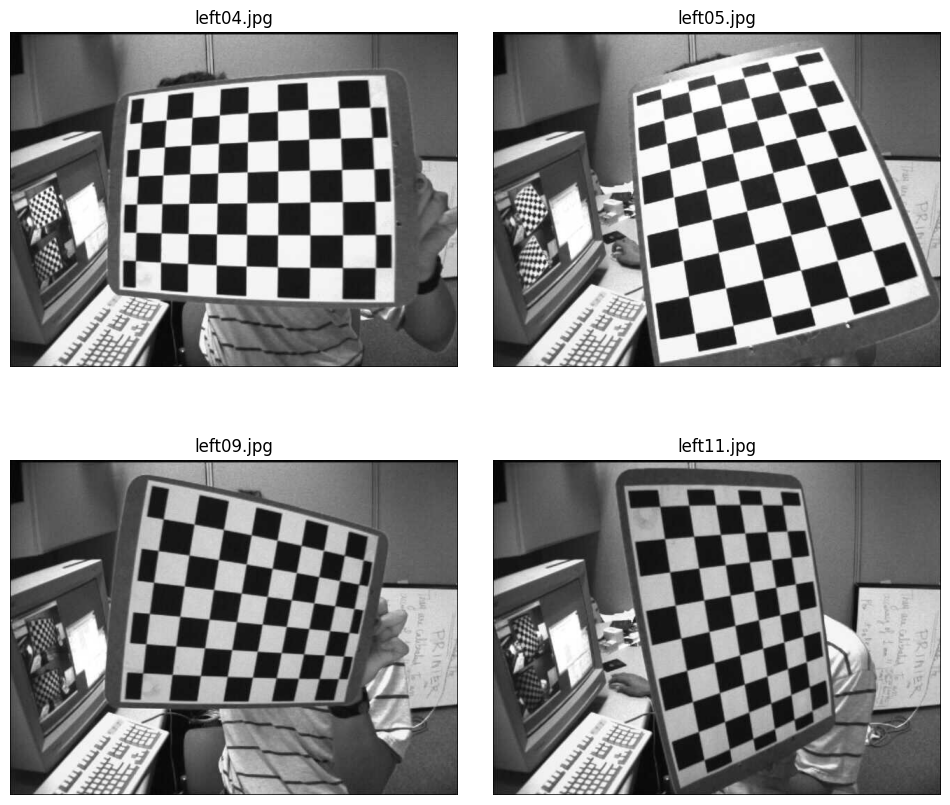

In [10]:
num_failed = len(failed_image_paths)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.subplots_adjust(hspace=0.25, wspace=0.08)

for ax, image_path in zip(axes.flat, failed_image_paths):
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    ax.imshow(image_rgb)
    ax.set_title(image_path.name)
    ax.axis("off")

for ax in axes.flat[num_failed:]:
    ax.axis("off")

plt.show()

## 4. Object points and image points

Camera calibration works by matching:

- **object points**: known 3D coordinates on the chessboard
- **image points**: detected 2D corner locations in the image

For a flat chessboard, all object points lie on the plane `z = 0`.

The square size sets the spacing between neighboring corners.
For learning, we can use `1.0` as an arbitrary unit.

### Important idea
These object points are **not** the global position of the board in the room.

They are the coordinates of the corners in the chessboard’s own local coordinate system.

That means the same object-point grid can be reused for every image.
What changes from image to image is the pose of the board relative to the camera.

In [11]:
objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

print("Object points shape:", objp.shape)
print("First 10 object points:")
print(objp[:10])

Object points shape: (42, 3)
First 10 object points:
[[0. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]
 [4. 0. 0.]
 [5. 0. 0.]
 [6. 0. 0.]
 [0. 1. 0.]
 [1. 1. 0.]
 [2. 1. 0.]]


In [12]:
object_points = [objp.copy() for _ in successful_image_paths]

print("Number of object-point sets:", len(object_points))
print("Number of image-point sets:", len(image_points))

Number of object-point sets: 9
Number of image-point sets: 9


### Theory: object points are board coordinates, not room coordinates

The object points are defined in the chessboard's own local coordinate frame.
For a flat board we choose:

$$Z = 0$$

for every corner, and define a regular grid in the $(X, Y)$ plane.

This does **not** mean we know where the board is in the room.
It only means we know the geometry of the board itself.

### Why the same object grid is reused for every image
The board geometry is fixed.
What changes from image to image is the board pose relative to the camera.
That pose is represented later by:
- a rotation vector
- a translation vector


## 5. Camera calibration

Now that we have object points and image points, we can estimate the camera parameters.

The two most important outputs are:
- the camera matrix
- the distortion coefficients

These parameters let us model how the camera projects 3D points into the image and how lens distortion affects that projection.

In [13]:
sample_gray = cv2.imread(str(successful_image_paths[0]), cv2.IMREAD_GRAYSCALE)
image_size = (sample_gray.shape[1], sample_gray.shape[0])  # width, height

ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    object_points,
    image_points,
    image_size,
    None,
    None,
)

print("Calibration RMS reprojection error:", ret)
print("\nCamera matrix:")
print(camera_matrix)

print("\nDistortion coefficients:")
print(dist_coeffs.ravel())

print("\nNumber of rotation vectors:", len(rvecs))
print("Number of translation vectors:", len(tvecs))

Calibration RMS reprojection error: 0.5123566383786138

Camera matrix:
[[533.25757015   0.         341.21541663]
 [  0.         533.00575917 234.56689346]
 [  0.           0.           1.        ]]

Distortion coefficients:
[-2.82332073e-01  2.26438587e-02  9.32606071e-05 -7.67546244e-04
  1.19023310e-01]

Number of rotation vectors: 9
Number of translation vectors: 9


### Theory: the calibration optimization problem

Calibration estimates parameters in the projection model:

$$x \approx K [R \mid t] X$$

where:
- $X$ is a 3D object point on the board
- $(R, t)$ is the board pose for one image
- $K$ is the camera intrinsic matrix

With distortion, the model also includes lens distortion coefficients.

### What `calibrateCamera` is solving
Across all successful images, OpenCV tries to find:
- one shared camera matrix
- one shared set of distortion coefficients
- one pose $(R_i, t_i)$ per image

so that the projected 3D board corners match the detected 2D image corners as closely as possible.

### Reprojection error
The returned RMS value summarizes how closely the model reprojects the known 3D corners back onto the detected 2D corners.
Smaller values indicate a better fit.

### Pseudocode
```text
for each successful image:
    pair object-point grid with detected image corners
optimize intrinsics, distortion, and per-image poses
minimize total reprojection error
return best-fit calibration parameters
```


### Interpretation

The calibration result gives:

- a **camera matrix**, which describes the intrinsic camera parameters
- **distortion coefficients**, which describe lens distortion
- one rotation vector and one translation vector for each successful image

### What looks reasonable here
- the RMS reprojection error is low enough to suggest a plausible fit
- `fx` and `fy` are close to each other
- the principal point is near the image center
- the distortion coefficients suggest mainly radial distortion

### Important idea
The camera matrix is shared across all images.
Rotation and translation are estimated separately for each image because the chessboard pose changes from view to view.

## 6. Undistortion

Once calibration parameters are known, we can try to undistort an image.

In a real camera pipeline, this is useful when the lens introduces visible geometric distortion.

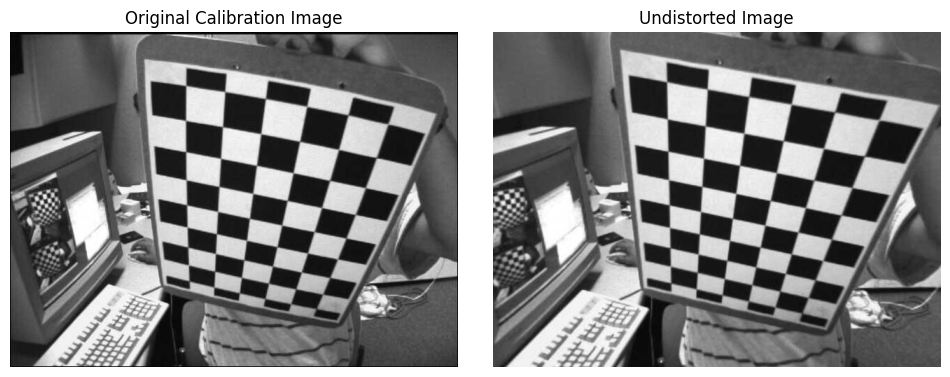

In [14]:
test_image_path = successful_image_paths[1]

image_bgr = cv2.imread(str(test_image_path), cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

undistorted_bgr = cv2.undistort(image_bgr, camera_matrix, dist_coeffs)
undistorted_rgb = cv2.cvtColor(undistorted_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.08)

axes[0].imshow(image_rgb)
axes[0].set_title("Original Calibration Image")
axes[0].axis("off")

axes[1].imshow(undistorted_rgb)
axes[1].set_title("Undistorted Image")
axes[1].axis("off")

plt.show()

### Theory: undistortion as geometric remapping

Lens distortion changes where scene points land in the image.
Undistortion applies the inverse geometric correction.

Conceptually:
- estimate the distortion model
- compute where each output pixel should sample from in the original image
- remap intensities accordingly

This is a geometric operation, not just an intensity adjustment.

### Why the visual effect may be subtle
If distortion is moderate, the correction can be small but still meaningful.
The strongest changes usually appear:
- near image borders
- along long straight structures
- where radial distortion is most visible


### Reflection

The undistorted image looks different, but the change is fairly subtle.

That is reasonable:
- the calibration result appears physically plausible
- the dataset comes from a real camera
- the lens distortion is not extremely strong

### Main lesson
A useful calibration result does not need to create a dramatic visual effect.
Even small geometric corrections can still be meaningful.

In practice, undistortion is often most noticeable near image borders and along long straight structures.

## Final Takeaways

### Technical takeaways
- OpenCV chessboard calibration uses **inner corners**, not the number of squares.
- Calibration matches known 3D object points with detected 2D image points.
- The same object-point grid can be reused for every image because it is defined in the chessboard’s local coordinate system.
- The camera matrix describes intrinsic camera parameters.
- Rotation and translation are estimated separately for each image because the board pose changes.
- Distortion coefficients model lens distortion, especially radial distortion.

### Practical takeaways
- Not every calibration image needs to succeed.
- A realistic calibration workflow often uses only the successful subset of images.
- Corner detection should always be checked visually.
- Undistortion can be useful even when the visual correction is subtle.

### What this notebook taught
- how to set up a calibration pattern correctly
- how to detect chessboard corners
- how to build object points and image points
- how to estimate camera parameters
- how to interpret calibration outputs instead of treating them as black-box numbers